In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Load data
df = pd.read_csv("heart (1).csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [3]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [4]:
# Split into features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 1: Train a Decision Tree classifier and visualize the tree

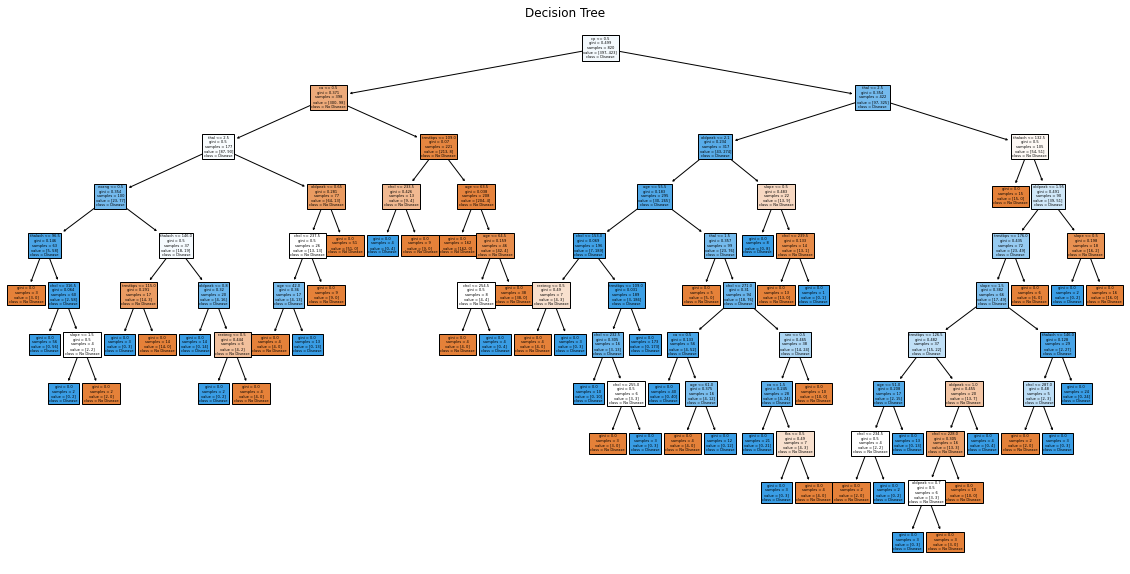

In [5]:
# 1.

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(tree_clf, feature_names=X.columns, class_names=["No Disease", "Disease"], filled=True)
plt.title("Decision Tree")
plt.show()

## 2: Analyze overfitting and control tree depth

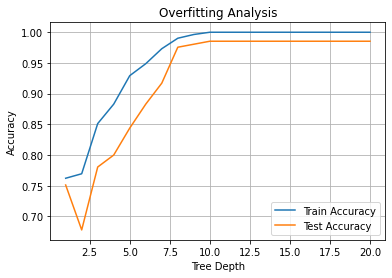

In [6]:
# 2. 

depths = list(range(1, 21))
train_acc, test_acc = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

plt.plot(depths, train_acc, label='Train Accuracy')
plt.plot(depths, test_acc, label='Test Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Overfitting Analysis')
plt.legend()
plt.grid(True)
plt.show()

## 3: Train random forest and compare accuracy

In [7]:
# 3. 

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Rendom Forest Accuracy:",rf_acc)

Rendom Forest Accuracy: 0.9853658536585366


## 4: Interpret feature importances

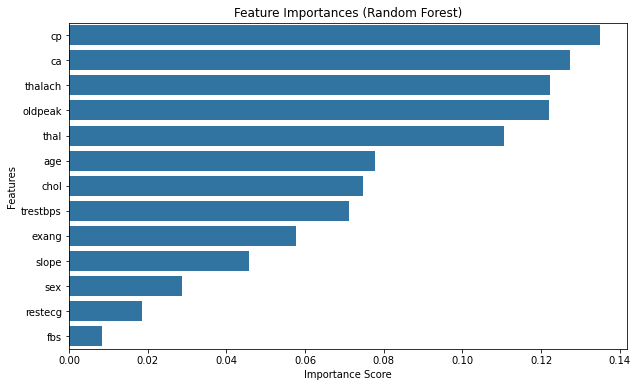

In [8]:
# 4.

importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## 5: Evaluate using cross-validation

In [9]:
# 5.

dt_scores = cross_val_score(tree_clf, X, y, cv=5)
rf_scores = cross_val_score(rf_clf, X, y, cv=5)

# Print results
print("Decision Tree Accuracy (Test Set):", tree_clf.score(X_test, y_test))
print("Random Forest Accuracy (Test Set):", rf_acc)
print("Decision Tree CV Accuracy (Mean):", dt_scores.mean())
print("Random Forest CV Accuracy (Mean):", rf_scores.mean())


Decision Tree Accuracy (Test Set): 0.9853658536585366
Random Forest Accuracy (Test Set): 0.9853658536585366
Decision Tree CV Accuracy (Mean): 1.0
Random Forest CV Accuracy (Mean): 0.9970731707317073
